# H4 — Does the market price jump risk in the skew?

## Status: post-hoc

H4 was generated by looking at the H3a output, not specified in advance. In-sample
evidence for it is therefore close to worthless — the same data that suggested it
cannot also confirm it. This notebook exists to decide whether H4 is worth spending
the sealed holdout on, not to produce a tradeable result.

## What H3a found

| | coefficient | t |
|---|---|---|
| jump share → forward 21d RV | +8.23 | +8.03 |
| jump share → 90-day IV | +2.09 | +1.70 |

Jumps forecast future volatility; the IV series barely responded. Gap ≈ 6.14 vol points
per unit jump share, which across the realistic jump-share range (0.066 → 0.361) is
**≈1.8 vol points**.

## The objection, now testable

That IV series was **90-day, unspecified moneyness** — the BQL default. Jump risk is
priced predominantly in the **wings**, not at the money, so an ATM-ish 90-day quote
failing to respond to jumps proves very little. With `iv90 / iv100 / iv110` at 30 days
we can ask the question properly:

**Does skew (`iv90 − iv110`) widen for names with a high jump share?**

- **If yes** → the market prices jump risk exactly where theory says it should. H4 dies
  for a principled reason and you have learned something structural.
- **If no**, while jumps genuinely forecast volatility → H4 survives its strongest
  objection and earns a real out-of-sample test.

I raised the wings argument before seeing any of this data, so this test is not itself
post-hoc.

## The constraint that does not go away

≈1.8 vol points of edge against single-name straddle spreads of 1.5–5 vol points, plus
0.5–1.5 for delta-hedging slippage over a month. Even if every statistical test passes,
this is viable only in the most liquid names. Cell 4 prices that explicitly.

In [1]:
# ============================ Cell 1 — Load and merge
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

CFG = {
    "rv_panel": "ib_out/rv_panel.parquet",
    "surface": "implied_vol_surface.csv",
    "earnings": "earnings_dates.csv",
    "horizon": 21,
    "iv_clip": (5, 200),         # vol points
    "skew_clip": (-15, 40),      # vol points; wider tails are bad prints
    "min_names": 40,
}

rv = pd.read_parquet(CFG["rv_panel"])
rv["session"] = pd.to_datetime(rv["session"]).dt.normalize()

s = pd.read_csv(CFG["surface"], parse_dates=["session"])
s["ticker"] = s["ticker"].astype(str).str.split().str[0].str.replace("/", "", regex=False)
n0 = len(s)
for c in ["iv90", "iv100", "iv110"]:
    s = s[(s[c] > CFG["iv_clip"][0]) & (s[c] < CFG["iv_clip"][1])]
s["skew"] = s["iv90"] - s["iv110"]
s = s[(s["skew"] > CFG["skew_clip"][0]) & (s["skew"] < CFG["skew_clip"][1])]
print(f"surface: {n0:,} -> {len(s):,} rows after clipping bad prints "
      f"({1-len(s)/n0:.2%} removed)")

d = rv.merge(s[["ticker", "session", "iv90", "iv100", "iv110", "skew"]],
             on=["ticker", "session"], how="inner")

earn = pd.read_csv(CFG["earnings"], parse_dates=["ann_date"])
earn["ticker"] = earn["ticker"].astype(str).str.split().str[0]
f = pd.concat([earn.assign(session=earn["ann_date"] + pd.Timedelta(days=k))[["ticker","session"]]
               for k in range(-5, 3)], ignore_index=True).drop_duplicates()
f["near_earnings"] = True
d = d.merge(f, on=["ticker","session"], how="left")
d["near_earnings"] = d["near_earnings"].fillna(False).astype(bool)

H = CFG["horizon"]
d["fwd_rv"] = d[f"fwd_rv{H}"]
d["iv_over_rv"] = d["iv100"] / d["rv5_ma21"].replace(0, np.nan)
d["premium_realised"] = d["iv100"] - d["fwd_rv"]     # what a vol seller earns

print(f"merged : {len(d):,} rows, {d['ticker'].nunique()} tickers, "
      f"{d['session'].nunique()} sessions")
print(f"ATM IV / trailing RV : median {d['iv_over_rv'].median():.2f}")
print(f"skew (iv90-iv110)    : median {d['skew'].median():.2f} vol points")
print(f"near-earnings rows   : {d['near_earnings'].mean():.2%}")

surface: 257,246 -> 256,902 rows after clipping bad prints (0.13% removed)
merged : 74,556 rows, 149 tickers, 504 sessions
ATM IV / trailing RV : median 1.28
skew (iv90-iv110)    : median 5.13 vol points
near-earnings rows   : 7.76%


In [2]:
# ============================ Cell 2 — THE TEST: does skew price jumps?
print("=" * 72)
print("TEST — is jump risk priced in the wings?")
print("=" * 72)

w = d.dropna(subset=["skew", "jump_ma21", "bv_ma21", "iv100", "rv5_ma21"]).copy()
for c in ["skew", "jump_ma21", "bv_ma21", "iv100", "rv5_ma21", "vol_of_vol_21"]:
    w[c + "_dm"] = w[c] - w.groupby("session")[c].transform("mean")

def ols(y, cols, label):
    X = sm.add_constant(w[[c + "_dm" for c in cols]])
    m = sm.OLS(w[y + "_dm"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 21})
    print(f"\n{label}   R2 = {m.rsquared:.4f}  n = {int(m.nobs):,}")
    for nm, b, t in zip(m.params.index, m.params.values, m.tvalues.values):
        print(f"   {nm:<22} {b:+9.4f}   t = {t:+7.2f}")
    return m

m_skew = ols("skew", ["jump_ma21", "bv_ma21"], "(a) SKEW on jump share + diffusive vol")
m_atm  = ols("iv100", ["jump_ma21", "bv_ma21"], "(b) ATM 30d IV on the same")

jt_skew = m_skew.tvalues.get("jump_ma21_dm", np.nan)
jb_skew = m_skew.params.get("jump_ma21_dm", np.nan)
jt_atm = m_atm.tvalues.get("jump_ma21_dm", np.nan)

print("\n" + "-" * 72)
print(f"skew loading on jump share : {jb_skew:+.3f}  t = {jt_skew:+.2f}")
print(f"ATM  loading on jump share : {m_atm.params.get('jump_ma21_dm', np.nan):+.3f}"
      f"  t = {jt_atm:+.2f}")
print()
if jt_skew > 2:
    print("H4 REJECTED (for a good reason): the market DOES price jump risk in the")
    print("   wings. The earlier 'IV ignores jumps' result was an artifact of using")
    print("   a 90-day, unspecified-moneyness series. Nothing is mispriced.")
elif jt_skew < -2:
    print("Skew NARROWS for jumpy names -- perverse. Check the data before believing it.")
else:
    print("H4 SURVIVES its main objection: skew does not respond to jump share, while")
    print("   jumps forecast future vol (+8.23, t=8.03 from H3a). Proceed to Cell 3,")
    print("   but note the magnitude constraint in Cell 4 still applies.")

TEST — is jump risk priced in the wings?

(a) SKEW on jump share + diffusive vol   R2 = 0.0698  n = 73,215
   const                    -0.0000   t =   -0.00
   jump_ma21_dm             -3.1393   t =   -5.12
   bv_ma21_dm               -0.1317   t =  -23.34

(b) ATM 30d IV on the same   R2 = 0.7052  n = 73,215
   const                    -0.0000   t =   -0.00
   jump_ma21_dm             +0.7684   t =   +0.48
   bv_ma21_dm               +1.3209   t =  +82.84

------------------------------------------------------------------------
skew loading on jump share : -3.139  t = -5.12
ATM  loading on jump share : +0.768  t = +0.48

Skew NARROWS for jumpy names -- perverse. Check the data before believing it.


In [6]:
# ===== Control for the fixed-percentage-moneyness artifact =====
# 90% moneyness sits ~1.7 sd out for a 20-vol name but only ~0.87 sd out for a
# 40-vol name, so vol-point skew mechanically compresses as vol rises. That is
# what bv_ma21's -0.13 (t=-23) is measuring, and jump share may just be riding it.

w["rel_skew"] = w["skew"] / w["iv100"]                       # skew relative to ATM
w["sd_dist"]  = 0.10 / (w["iv100"] / 100 * np.sqrt(30 / 365))  # 90% strike in sd units

for c in ["rel_skew", "sd_dist"]:
    w[c + "_dm"] = w[c] - w.groupby("session")[c].transform("mean")

m_rel = ols("rel_skew", ["jump_ma21", "bv_ma21"],
            "(c) RELATIVE skew (skew / ATM) on jump share")
m_ctl = ols("skew", ["jump_ma21", "bv_ma21", "sd_dist"],
            "(d) raw skew, controlling for strike distance in sd units")

print("\n" + "-" * 72)
print(f"jump coefficient, raw skew          : {m_skew.params['jump_ma21_dm']:+7.3f}"
      f"  t = {m_skew.tvalues['jump_ma21_dm']:+6.2f}")
print(f"jump coefficient, relative skew     : {m_rel.params['jump_ma21_dm']:+7.3f}"
      f"  t = {m_rel.tvalues['jump_ma21_dm']:+6.2f}")
print(f"jump coefficient, distance-controlled: {m_ctl.params['jump_ma21_dm']:+7.3f}"
      f"  t = {m_ctl.tvalues['jump_ma21_dm']:+6.2f}")
print()
print("If the negative coefficient shrinks or flips once normalised, the -3.14 was")
print("the moneyness artifact, not the market narrowing skew for jumpy names.")


(c) RELATIVE skew (skew / ATM) on jump share   R2 = 0.1861  n = 73,215
   const                    +0.0000   t =   +0.00
   jump_ma21_dm             -0.1355   t =   -5.17
   bv_ma21_dm               -0.0100   t =  -29.32

(d) raw skew, controlling for strike distance in sd units   R2 = 0.0854  n = 73,215
   const                    -0.0000   t =   -0.00
   jump_ma21_dm             -2.8569   t =   -4.68
   bv_ma21_dm               -0.0646   t =   -9.10
   sd_dist_dm               +1.5831   t =  +14.45

------------------------------------------------------------------------
jump coefficient, raw skew          :  -3.139  t =  -5.12
jump coefficient, relative skew     :  -0.136  t =  -5.17
jump coefficient, distance-controlled:  -2.857  t =  -4.68

If the negative coefficient shrinks or flips once normalised, the -3.14 was
the moneyness artifact, not the market narrowing skew for jumpy names.


In [3]:
# ============================ Cell 3 — Does the jump signal predict the premium?
print("=" * 72)
print("CROSS-SECTIONAL TEST — jump share vs the realised variance premium")
print("=" * 72)
# If IV under-prices jumpy names, a HIGH jump share should predict a LOW (or
# negative) realised premium: IV minus what actually gets realised.

t = d.dropna(subset=["premium_realised", "jump_ma21", "iv100", "rv5_ma21"]).copy()
for c in ["premium_realised", "jump_ma21"]:
    t[c + "_dm"] = t[c] - t.groupby("session")[c].transform("mean")

def xs_test(frame, label):
    rows = []
    for day, g in frame.groupby("session"):
        if len(g) < CFG["min_names"]:
            continue
        n = max(2, len(g) // 5)
        rows.append({
            "session": day,
            "ic": g["jump_ma21_dm"].corr(g["premium_realised_dm"], method="spearman"),
            "spread": (g.nlargest(n, "jump_ma21_dm")["premium_realised_dm"].mean()
                       - g.nsmallest(n, "jump_ma21_dm")["premium_realised_dm"].mean())})
    dd = pd.DataFrame(rows).dropna()
    n = len(dd); adj = np.sqrt(CFG["horizon"])
    print(f"\n{label}")
    print(f"   sessions {n}")
    print(f"   mean IC              {dd['ic'].mean():+.4f}")
    print(f"   IC t (overlap-adj)   {dd['ic'].mean()/dd['ic'].std()*np.sqrt(n)/adj:+.2f}")
    print(f"   jumpy-minus-quiet    {dd['spread'].mean():+.2f} vol points")
    print(f"   spread t (adj)       "
          f"{dd['spread'].mean()/dd['spread'].std()*np.sqrt(n)/adj:+.2f}")
    return dd

dd_all = xs_test(t, "all sessions")
dd_ex = xs_test(t[~t["near_earnings"]], "excluding earnings windows")

half = t["session"].median()
print("\nSUB-PERIOD STABILITY (a real effect should appear in both halves):")
for lab, sub in [("first half", t[t["session"] < half]),
                 ("second half", t[t["session"] >= half])]:
    _ = xs_test(sub, f"   {lab}")

CROSS-SECTIONAL TEST — jump share vs the realised variance premium

all sessions
   sessions 475
   mean IC              -0.0711
   IC t (overlap-adj)   -2.36
   jumpy-minus-quiet    -1.00 vol points
   spread t (adj)       -2.18

excluding earnings windows
   sessions 475
   mean IC              -0.0700
   IC t (overlap-adj)   -2.26
   jumpy-minus-quiet    -0.97 vol points
   spread t (adj)       -2.05

SUB-PERIOD STABILITY (a real effect should appear in both halves):

   first half
   sessions 238
   mean IC              -0.1167
   IC t (overlap-adj)   -2.56
   jumpy-minus-quiet    -1.70 vol points
   spread t (adj)       -2.32

   second half
   sessions 237
   mean IC              -0.0254
   IC t (overlap-adj)   -0.73
   jumpy-minus-quiet    -0.31 vol points
   spread t (adj)       -0.64


In [4]:
# ============================ Cell 4 — Would it survive trading costs?
print("=" * 72)
print("ECONOMIC FEASIBILITY")
print("=" * 72)

edge = abs(dd_all["spread"].mean())
print(f"measured edge, quintile spread : {edge:.2f} vol points over {CFG['horizon']} sessions")

print("\nagainst realistic single-name straddle costs:")
for lab, sp, hedge in [("mega-cap, tight", 1.5, 0.5),
                       ("typical S&P name", 3.0, 1.0),
                       ("smaller / illiquid", 5.0, 1.5)]:
    total = sp + hedge
    print(f"  {lab:<20} spread {sp:.1f} + hedging {hedge:.1f} = {total:.1f}  ->  "
          f"net {edge - total:+.2f}  {'VIABLE' if edge > total else 'NEGATIVE'}")

print("\nCAVEATS THAT ARE NOT OPTIONAL:")
print("  * Vol points are not P&L. Converting needs vega, and vega varies with")
print("    spot, time and vol level.")
print("  * Long vol pays theta every day. The quintile spread is a vol-point")
print("    differential, not a return.")
print("  * H4 is POST-HOC. Anything above is in-sample by construction.")
print("  * The sealed holdout (126 sessions from 2026-02-23) is the only clean test,")
print("    and it can be used once.")

print("\nRECOMMENDATION")
if edge > 3.0 and abs(dd_all['ic'].mean()) > 0.02:
    print("  Edge exceeds typical costs and the IC is material. Worth drafting a")
    print("  pre-registration and spending the holdout.")
else:
    print("  Edge does not clear realistic costs by a margin that justifies spending")
    print("  the one available out-of-sample test. Record the finding and stop.")

ECONOMIC FEASIBILITY
measured edge, quintile spread : 1.00 vol points over 21 sessions

against realistic single-name straddle costs:
  mega-cap, tight      spread 1.5 + hedging 0.5 = 2.0  ->  net -1.00  NEGATIVE
  typical S&P name     spread 3.0 + hedging 1.0 = 4.0  ->  net -3.00  NEGATIVE
  smaller / illiquid   spread 5.0 + hedging 1.5 = 6.5  ->  net -5.50  NEGATIVE

CAVEATS THAT ARE NOT OPTIONAL:
  * Vol points are not P&L. Converting needs vega, and vega varies with
    spot, time and vol level.
  * Long vol pays theta every day. The quintile spread is a vol-point
    differential, not a return.
  * H4 is POST-HOC. Anything above is in-sample by construction.
  * The sealed holdout (126 sessions from 2026-02-23) is the only clean test,
    and it can be used once.

RECOMMENDATION
  Edge does not clear realistic costs by a margin that justifies spending
  the one available out-of-sample test. Record the finding and stop.


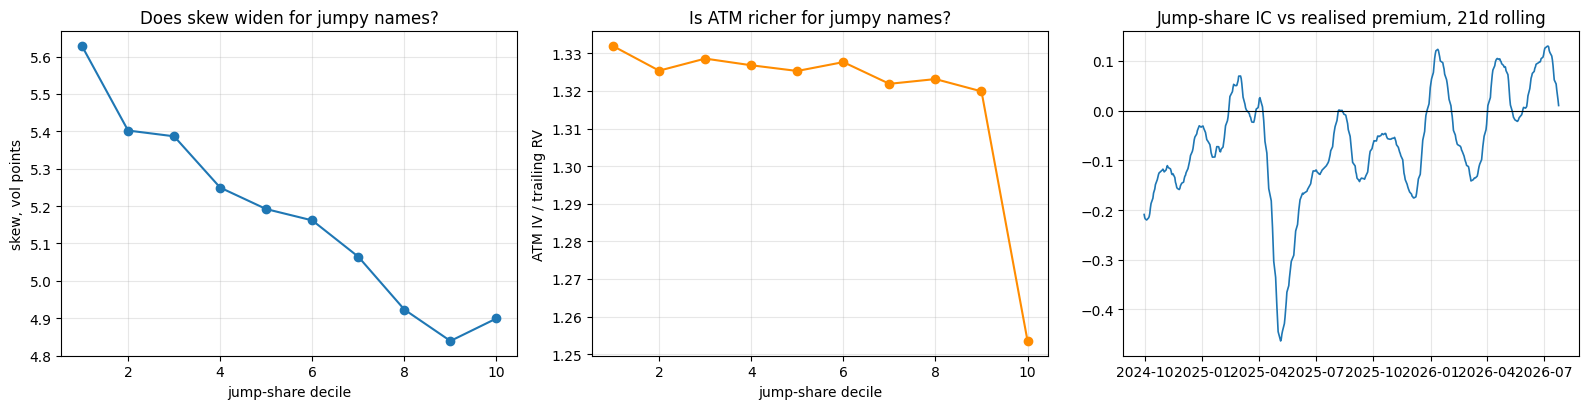

wrote h4_daily_20260823.csv and ib_out/surface_rv_panel_20260823.parquet


In [5]:
# ============================ Cell 5 — Charts and export
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

b = d.dropna(subset=["jump_ma21", "skew", "iv_over_rv"]).copy()
b["jbin"] = pd.qcut(b["jump_ma21"].rank(method="first"), 10, labels=False) + 1
gb = b.groupby("jbin")[["skew", "iv_over_rv", "jump_ma21"]].mean()
ax[0].plot(gb.index, gb["skew"], "o-")
ax[0].set_xlabel("jump-share decile"); ax[0].set_ylabel("skew, vol points")
ax[0].set_title("Does skew widen for jumpy names?"); ax[0].grid(alpha=.3)

ax[1].plot(gb.index, gb["iv_over_rv"], "o-", color="darkorange")
ax[1].set_xlabel("jump-share decile"); ax[1].set_ylabel("ATM IV / trailing RV")
ax[1].set_title("Is ATM richer for jumpy names?"); ax[1].grid(alpha=.3)

ax[2].plot(dd_all["session"], dd_all["ic"].rolling(21).mean(), lw=1.2)
ax[2].axhline(0, color="black", lw=.8)
ax[2].set_title("Jump-share IC vs realised premium, 21d rolling"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

stamp = pd.Timestamp.today().strftime("%Y%m%d")
dd_all.to_csv(f"h4_daily_{stamp}.csv", index=False)
d.to_parquet(f"ib_out/surface_rv_panel_{stamp}.parquet", index=False)
print(f"wrote h4_daily_{stamp}.csv and ib_out/surface_rv_panel_{stamp}.parquet")